# Czech UGS Storage Target — Season-Long Draw-Down Simulation

**Question this notebook answers**  
What working-gas volume must Czech UGS hold on **1 October** so that a 1-in-20 cold-winter demand event can be survived without shortfall, at each import-risk scenario (S1–S5)?

**Approach** — A daily draw-down simulation over the full Oct–Mar season (182 days), integrating three previously-developed inputs:
1. Month-specific 1-in-20 peak demand (from `data/r_max_den_2025-2026.csv`).
2. Month-specific import percentiles per scenario (from post-2022 ENTSOG Physical Flows).
3. Fill-dependent withdrawal capacity curve (isotonic fit from `withdrawal_curve.ipynb`).

For each scenario we bisect on starting fill level to find the **minimum** percentage of working-gas capacity that keeps the simulation feasible across all 182 days.  Two failure modes are tracked separately:
- **Volume binding** — storage runs empty.
- **Withdrawal-rate binding** — gas remains but max deliverability falls below the daily gap.

**Unit conventions** — energy: GWh; rates: GWh/d; fill: percentage points of working-gas capacity. Capacity is `45.3034 TWh = 45,303.4 GWh`. Conversion of a daily gap into a percentage-point drop in fill: `Δfill_pp = daily_gap_GWh / (capacity_TWh × 10)`.

---
## 0. Setup

In [1]:
%cd ..

/Users/martinsik/Coding/bsd_revamp


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.interpolate import interp1d
from sklearn.isotonic import IsotonicRegression

import bsd.data as bdata
import bsd.jvs as jvs

jvs.apply_style(theme="light", context="notebook")

_sc = jvs.PALETTES["scenarios"]

%matplotlib inline

DATA_FILE    = bdata.DATA_PATH_IMPORTS
PEAK_FILE    = bdata.DATA_PATH_DEMAND_PEAK
STORAGE_FILE = bdata.DATA_PATH_STORAGE_GIE
CUTOFF       = bdata.DEFAULT_CUTOFF

CAPACITY_TWH = 45.3034
CAPACITY_GWH = CAPACITY_TWH * 1000

SCENARIOS = {
    "S1": {"label": "S1 — High stress",   "percentile": 10, "color": _sc[0]},
    "S2": {"label": "S2 — Stressed",      "percentile": 20, "color": _sc[1]},
    "S3": {"label": "S3 — Base stressed", "percentile": 30, "color": _sc[2]},
    "S4": {"label": "S4 — Median",        "percentile": 50, "color": _sc[3]},
    "S5": {"label": "S5 — Favourable",    "percentile": 70, "color": _sc[4]},
}

MONTH_ORDER = [10, 11, 12, 1, 2, 3]
MONTH_NAMES = {10: "Oct", 11: "Nov", 12: "Dec", 1: "Jan", 2: "Feb", 3: "Mar"}
DAYS_IN_MONTH = {10: 31, 11: 30, 12: 31, 1: 31, 2: 28, 3: 31}
# Withdrawal curve assumption
# 'empirical'   — P95 isotonic fit from observed GIE data (conservative floor)
# 'engineering' — ENTSOG declared technical capacity with haircut (ceiling)
# 'blend'       — weighted average (default; recommended for regulatory use)
WC_ASSUMPTION       = "blend"
WC_HAIRCUT          = 0.10   # applied to engineering curve before blending
WC_BLEND_WEIGHT_ENG = 0.75   # higher eng weight for Branch 2: better identified at low fill

# Import capacity assumption
# 'scenarios'        — five S1–S5 percentile bands (default; risk axis)
# 'p99_cold'         — P99 of imports on cold days (top-COLD_DAY_QUANTILE withdrawal)
# 'p99_unconditional'— P99 of imports across all winter days
IMPORT_ASSUMPTION  = "p99_cold"
COLD_DAY_QUANTILE  = 0.80


---
## 1. Monthly peak demand (1-in-20)

In [3]:
peak_raw = pd.read_csv(PEAK_FILE)
peak_raw.columns = peak_raw.columns.str.strip()
MONTH_NUM = {"october": 10, "november": 11, "december": 12,
             "january": 1, "february": 2, "march": 3}
peak_raw["month_num"] = peak_raw["month"].str.lower().map(MONTH_NUM)
peak_raw["peak_GWh_d"] = peak_raw["value [mhw]"] / 1000

peak_demand = (
    peak_raw.set_index("month_num")["peak_GWh_d"]
    .reindex(MONTH_ORDER)
)
peak_demand

month_num
10    163.239
11    244.370
12    325.367
1     367.774
2     326.700
3     244.642
Name: peak_GWh_d, dtype: float64

---
## 2. Monthly import percentiles per scenario

In [4]:
daily = bdata.load_daily_imports(DATA_FILE, cutoff=CUTOFF)
winter = daily[daily["month"].isin(MONTH_ORDER)].copy()

monthly_imports = {}
for key, sc in SCENARIOS.items():
    monthly_imports[key] = pd.Series(
        {m: winter[winter["month"] == m]["GWh_d"].quantile(sc["percentile"] / 100)
         for m in MONTH_ORDER}
    )

# Cold-day P99: identify top-COLD_DAY_QUANTILE withdrawal days per month
_sto = pd.read_csv(STORAGE_FILE, sep=";", parse_dates=["Gas Day Start (status at 6AM  CEST)"])
_sto.columns = _sto.columns.str.strip()
_sto = _sto.rename(columns={"Gas Day Start (status at 6AM  CEST)": "date",
                             "Withdrawal (GWh/d)": "withdrawal"})
_sto["date_key"] = pd.to_datetime(_sto["date"]).dt.normalize()
_w = winter.copy(); _w["date_key"] = _w["date"].dt.normalize()
_merged = _w.merge(_sto[["date_key", "withdrawal"]].dropna(), on="date_key", how="inner")

_cold_mask = pd.Series(False, index=_merged.index)
for _m in MONTH_ORDER:
    _mask = _merged["month"] == _m
    _thresh = _merged.loc[_mask, "withdrawal"].quantile(COLD_DAY_QUANTILE)
    _cold_mask = _cold_mask | (_mask & (_merged["withdrawal"] >= _thresh))

monthly_imports_p99_uncond = pd.Series(
    {m: _merged[_merged["month"] == m]["GWh_d"].quantile(0.99) for m in MONTH_ORDER}
)
monthly_imports_p99_cold = pd.Series(
    {m: _merged.loc[(_merged["month"] == m) & _cold_mask, "GWh_d"].quantile(0.99)
     for m in MONTH_ORDER}
)
IMPORT_CEILING = {"p99_cold": monthly_imports_p99_cold,
                  "p99_unconditional": monthly_imports_p99_uncond}[IMPORT_ASSUMPTION]

monthly_imports_df = pd.DataFrame(monthly_imports).round(1)
monthly_imports_df.index = [MONTH_NAMES[m] for m in MONTH_ORDER]
monthly_imports_df["P99 unconditional"] = monthly_imports_p99_uncond.values.round(1)
monthly_imports_df["P99 cold days"]     = monthly_imports_p99_cold.values.round(1)
print(f"Active ceiling assumption: {IMPORT_ASSUMPTION}")
monthly_imports_df

---
## 3. Withdrawal curve fit (relative + absolute)

Fitting code reused verbatim from `withdrawal_curve.ipynb` so this notebook is self-contained.

In [5]:
raw = pd.read_csv(STORAGE_FILE, sep=";",
                  parse_dates=["Gas Day Start (status at 6AM  CEST)"],
                  dayfirst=False, decimal=".")
raw.columns = raw.columns.str.strip()
raw = raw.rename(columns={
    "Gas Day Start (status at 6AM  CEST)": "date",
    "Full (%)":                            "fill_pct",
    "Withdrawal (GWh/d)":                  "withdrawal",
    "Withdrawal capacity (GWh/d)":         "wc_declared",
})
sto = raw[["date", "fill_pct", "withdrawal", "wc_declared"]].dropna()
sto["month"] = sto["date"].dt.month
wint = sto[(sto["date"] >= CUTOFF) & sto["month"].isin(bdata.WINTER_MONTHS)].copy()
wint["util_ratio"] = wint["withdrawal"] / wint["wc_declared"]

WC_CURRENT = wint.loc[wint["date"] == wint["date"].max(), "wc_declared"].iloc[0]

BIN_EDGES  = np.arange(0, 105, 5)
BIN_LABELS = (BIN_EDGES[:-1] + 2.5).astype(float)
QUANTILE   = 0.95
MIN_OBS    = 5

wint["fill_bin"] = pd.cut(wint["fill_pct"], bins=BIN_EDGES,
                          labels=BIN_LABELS, right=False).astype(float)
bins = (wint.groupby("fill_bin", observed=False)
        .agg(n=("withdrawal", "count"),
             p95_abs=("withdrawal", lambda x: x.quantile(QUANTILE)),
             p95_ratio=("util_ratio", lambda x: x.quantile(QUANTILE)))
        .reset_index().rename(columns={"fill_bin": "fill_mid"}))
bins["p95_rel"] = bins["p95_ratio"] * WC_CURRENT
bins["reliable"] = bins["n"] >= MIN_OBS

reliable = bins[bins["reliable"]]
ir_abs = IsotonicRegression(increasing=True, out_of_bounds="clip")
ir_abs.fit(reliable["fill_mid"], reliable["p95_abs"])
ir_rel = IsotonicRegression(increasing=True, out_of_bounds="clip")
ir_rel.fit(reliable["fill_mid"], reliable["p95_rel"])

fill_all = bins["fill_mid"].values
bins["curve_abs"] = ir_abs.predict(fill_all)
bins["curve_rel"] = ir_rel.predict(fill_all)

wc_curve_abs = interp1d(
    fill_all, bins["curve_abs"].values, kind="linear",
    bounds_error=False,
    fill_value=(bins["curve_abs"].iloc[0], bins["curve_abs"].iloc[-1]),
)
wc_curve_rel = interp1d(
    fill_all, bins["curve_rel"].values, kind="linear",
    bounds_error=False,
    fill_value=(bins["curve_rel"].iloc[0], bins["curve_rel"].iloc[-1]),
)

def wc(fill_pct):
    return float(wc_curve_rel(np.clip(fill_pct, 0, 100)))


# ── ENTSOG engineering curve (with haircut) ───────────────────────────────
_eng = pd.read_csv(Path("data/cz_usg_withdrawal_curve_2025.csv")).sort_values("percentile")
_eng_fill  = _eng["percentile"].values * 100
_eng_ratio = _eng["value"].values * (1 - WC_HAIRCUT)
_wc_engineering_interp = interp1d(
    _eng_fill, _eng_ratio * WC_CURRENT, kind="linear",
    bounds_error=False,
    fill_value=(_eng_ratio[0] * WC_CURRENT, _eng_ratio[-1] * WC_CURRENT),
)

def wc_engineering(fill_pct):
    return float(_wc_engineering_interp(np.clip(fill_pct, 0, 100)))

def wc_blend(fill_pct):
    w = WC_BLEND_WEIGHT_ENG
    return (1 - w) * wc_empirical(fill_pct) + w * wc_engineering(fill_pct)

wc_empirical = wc   # keep empirical accessible for sensitivity analysis
wc = {"empirical": wc_empirical, "engineering": wc_engineering, "blend": wc_blend}[WC_ASSUMPTION]

print(f"WC assumption: {WC_ASSUMPTION}  (haircut={WC_HAIRCUT:.0%}, eng_weight={WC_BLEND_WEIGHT_ENG:.0%})")
print(f"WC at 20%: {wc(20):.1f}  50%: {wc(50):.1f}  80%: {wc(80):.1f}  GWh/d")


---
## 4. Simulation engine

**Daily update.** Within month `m`, daily gap `g_m = max(0, peak_m − imp_m[scenario])`. At each day `t`:
1. `max_wc_t = wc(fill_pct_t)`.
2. **Withdrawal-rate feasibility**: if `max_wc_t < g_m`, mark infeasible (withdrawal-rate binding).
3. Compute `Δfill_pp = g_m / (CAPACITY_TWH × 10)` and update `fill_pct_{t+1} = fill_pct_t − Δfill_pp`.
4. **Volume feasibility**: if `fill_pct_{t+1} < 0`, mark infeasible (volume binding).

Simulation runs 182 days (Oct 1 → Mar 31, non-leap-Feb). Withdrawal is purely a function of fill level — actual deliveries are not net of any opportunistic surplus, consistent with the deterministic stress framing.

In [6]:
def build_day_series(peak_demand, scenario_imports):
    """Return per-day arrays of (month, peak, import, gap) over Oct 1 → Mar 31."""
    months, peaks, imps, gaps = [], [], [], []
    for m in MONTH_ORDER:
        d = DAYS_IN_MONTH[m]
        p = float(peak_demand.loc[m])
        i = float(scenario_imports.loc[m])
        g = max(0.0, p - i)
        months.extend([m] * d); peaks.extend([p] * d); imps.extend([i] * d); gaps.extend([g] * d)
    return (np.array(months), np.array(peaks), np.array(imps), np.array(gaps))

def simulate(start_fill_pct, scenario_key, *,
             capacity_TWh=CAPACITY_TWH, wc_func=wc,
             peak_demand=peak_demand, monthly_imports=monthly_imports):
    months, peaks, imps, gaps = build_day_series(peak_demand, monthly_imports[scenario_key])
    n = len(gaps)
    fill_traj = np.empty(n + 1); fill_traj[0] = start_fill_pct
    wd_traj   = np.empty(n)
    headroom  = np.empty(n)
    feasible = True
    day_inf  = None
    binding  = None
    delta_per_gwh = 1.0 / (capacity_TWh * 10)
    for t in range(n):
        max_wc = wc_func(fill_traj[t])
        wd_traj[t]  = max_wc
        headroom[t] = max_wc - gaps[t]
        if max_wc < gaps[t] - 1e-9:
            feasible = False; day_inf = t; binding = "withdrawal rate"; break
        fill_traj[t + 1] = fill_traj[t] - gaps[t] * delta_per_gwh
        if fill_traj[t + 1] < -1e-9:
            feasible = False; day_inf = t; binding = "volume"; break
    valid_until = (day_inf if day_inf is not None else n)
    return {
        "feasible":            feasible,
        "min_fill_pct":        float(fill_traj[:valid_until + 1].min()),
        "day_of_infeasibility": day_inf,
        "binding_constraint":  binding,
        "fill_trajectory":     fill_traj[:valid_until + 1].tolist(),
        "withdrawal_trajectory": wd_traj[:valid_until].tolist(),
        "headroom_trajectory": headroom[:valid_until].tolist(),
        "daily_gap":           gaps,
    }

simulate(80.0, "S2")["feasible"], simulate(10.0, "S2")["feasible"]

(True, False)

---
## 5. Bisection on starting fill level

In [7]:
def min_start_fill(scenario_key, *, tol=0.01, lo=0.0, hi=100.0, **sim_kwargs):
    if not simulate(hi, scenario_key, **sim_kwargs)["feasible"]:
        return None
    if simulate(lo, scenario_key, **sim_kwargs)["feasible"]:
        return lo
    while hi - lo > tol:
        mid = (lo + hi) / 2
        if simulate(mid, scenario_key, **sim_kwargs)["feasible"]:
            hi = mid
        else:
            lo = mid
    return hi

main_results = {}
for key in SCENARIOS:
    f = min_start_fill(key)
    sim = simulate(f, key) if f is not None else None
    main_results[key] = {"start_fill_pct": f, "sim": sim}
    if f is None:
        print(f"{key}: INFEASIBLE at 100% start fill — withdrawal curve cannot meet daily gap")
    else:
        print(f"{key}: start fill = {f:5.2f}%  ({f * CAPACITY_TWH / 100:5.2f} TWh)  "
              f"min fill = {sim['min_fill_pct']:5.2f}%  binding = {sim['binding_constraint'] or '— (just feasible)'}")

S1: start fill = 76.00%  (34.43 TWh)  min fill = 20.32%  binding = — (just feasible)
S2: start fill = 70.07%  (31.75 TWh)  min fill = 21.64%  binding = — (just feasible)
S3: start fill = 58.59%  (26.54 TWh)  min fill = 21.02%  binding = — (just feasible)
S4: start fill = 38.73%  (17.54 TWh)  min fill = 16.79%  binding = — (just feasible)
S5: start fill = 11.67%  ( 5.29 TWh)  min fill =  0.00%  binding = — (just feasible)


The 'binding constraint' on the just-feasible solution is identified by re-running simulation at a starting fill 0.05 pp lower and observing which failure occurs first.

In [8]:
for key, info in main_results.items():
    f = info["start_fill_pct"]
    if f is None:
        info["binding"] = "infeasible at 100%"; continue
    probe = simulate(max(0.0, f - 0.05), key)
    info["binding"] = probe["binding_constraint"] or "volume"
    print(f"{key}: binding constraint at threshold = {info['binding']}")

S1: binding constraint at threshold = withdrawal rate
S2: binding constraint at threshold = withdrawal rate
S3: binding constraint at threshold = withdrawal rate
S4: binding constraint at threshold = withdrawal rate
S5: binding constraint at threshold = volume


---
## 6. Sensitivity analysis

Vary peak demand uniformly by ±50 GWh/d across all months and re-solve. Separately, swap the relative curve for the absolute curve. All units consistent with the main run.

In [9]:
def wc_abs(fill_pct):
    return float(wc_curve_abs(np.clip(fill_pct, 0, 100)))

sens_rows = []
for key in SCENARIOS:
    base = main_results[key]["start_fill_pct"]
    base_twh = None if base is None else base * CAPACITY_TWH / 100

    def solve(peak_shift=0.0, wc_func=wc):
        shifted = peak_demand + peak_shift
        f = min_start_fill(key, peak_demand=shifted, wc_func=wc_func)
        return None if f is None else f * CAPACITY_TWH / 100

    sens_rows.append({
        "scenario":           key,
        "base_TWh":           round(base_twh, 2) if base_twh is not None else None,
        "peak +50_TWh":       round(solve(peak_shift=+50), 2) if solve(peak_shift=+50) is not None else "infeasible",
        "peak −50_TWh":       round(solve(peak_shift=-50), 2) if solve(peak_shift=-50) is not None else None,
        "wc_abs curve_TWh":   round(solve(wc_func=wc_abs), 2) if solve(wc_func=wc_abs) is not None else "infeasible",
    })

sens_df = pd.DataFrame(sens_rows).set_index("scenario")
sens_df

,base_TWh,peak +50_TWh,peak −50_TWh,wc_abs curve_TWh
scenario,,,,
S1,34.43,44.12,27.21,35.55
S2,31.75,39.05,24.53,33.12
S3,26.54,33.76,19.37,28.02
S4,17.54,25.66,5.44,20.80
S5,5.29,19.52,2.34,13.28


---
## 6b. Ceiling benchmark — P99 import capacity

Season-long target (1-Oct fill) assuming imports reach the P99 ceiling.
Complements the main S1–S5 table; controlled by `IMPORT_ASSUMPTION`.

In [ ]:
f_ceil = min_start_fill("S2", monthly_imports={m: IMPORT_CEILING for m in ["S2"]},
                        peak_demand=peak_demand) if False else None
# Run for all scenarios under ceiling imports
ceiling_target = {}
for key in SCENARIOS:
    _imp = {k: IMPORT_CEILING for k in SCENARIOS}
    f = min_start_fill(key, monthly_imports=_imp)
    ceiling_target[key] = {
        "Start fill (TWh)": round(f * CAPACITY_TWH / 100, 2) if f is not None else None,
        "Start fill (%)": round(f, 2) if f is not None else None,
    }

ceiling_df = pd.DataFrame(ceiling_target).T
ceiling_df.index = [SCENARIOS[k]["label"] for k in SCENARIOS]
print(f"Season target under {IMPORT_ASSUMPTION} ceiling imports (GWh/d):")
print(IMPORT_CEILING.rename(MONTH_NAMES).round(1).to_string())
print()
print("vs. base scenario targets (S2 base:", round(main_results["S2"]["start_fill_pct"]*CAPACITY_TWH/100,2), "TWh)")
ceiling_df

---
## 7. Charts

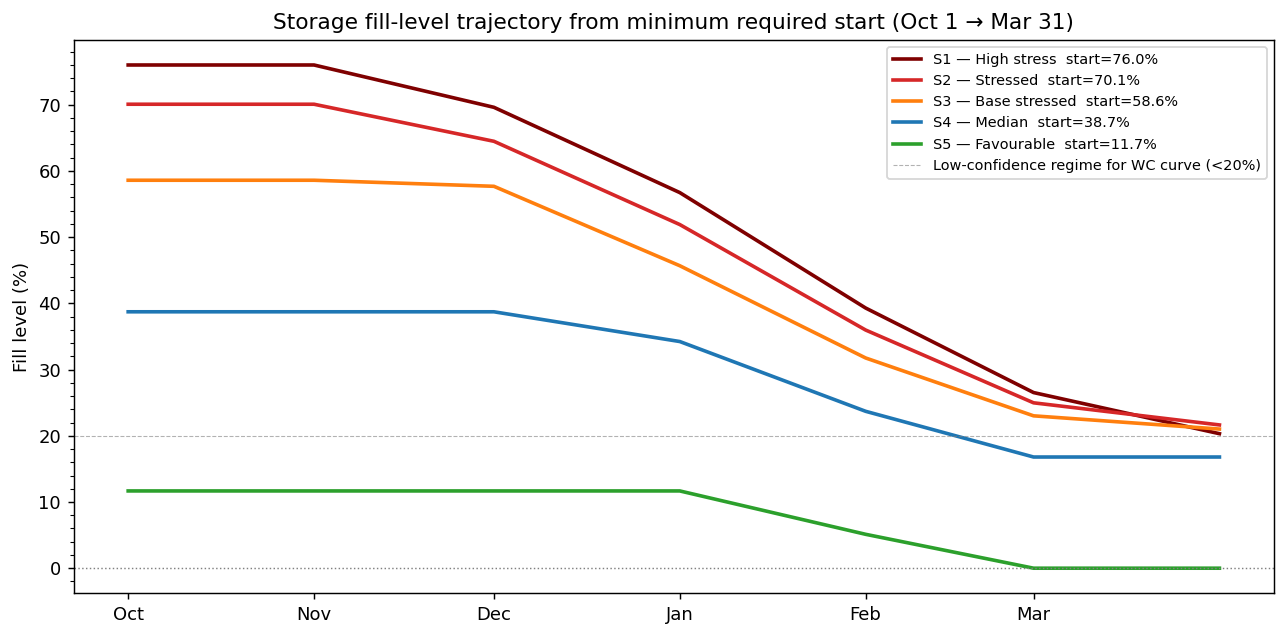

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
month_starts = np.cumsum([0] + [DAYS_IN_MONTH[m] for m in MONTH_ORDER[:-1]])
for key, sc in SCENARIOS.items():
    info = main_results[key]
    if info["sim"] is None: continue
    traj = info["sim"]["fill_trajectory"]
    ax.plot(range(len(traj)), traj, color=sc["color"], lw=2,
            label=f"{sc['label']}  start={info['start_fill_pct']:.1f}%")
ax.set_xticks(month_starts)
ax.set_xticklabels([MONTH_NAMES[m] for m in MONTH_ORDER])
ax.set_ylabel("Fill level (%)")
ax.set_title("Storage fill-level trajectory from minimum required start (Oct 1 → Mar 31)")
ax.axhline(0, color="grey", lw=0.8, ls=":")
ax.axhline(20, color="grey", lw=0.6, ls="--", alpha=0.6,
           label="Low-confidence regime for WC curve (<20%)")
ax.legend(fontsize=8)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
fig.tight_layout()
fig.savefig("figs/storage_target_fill_trajectories.png", bbox_inches="tight")
fig;

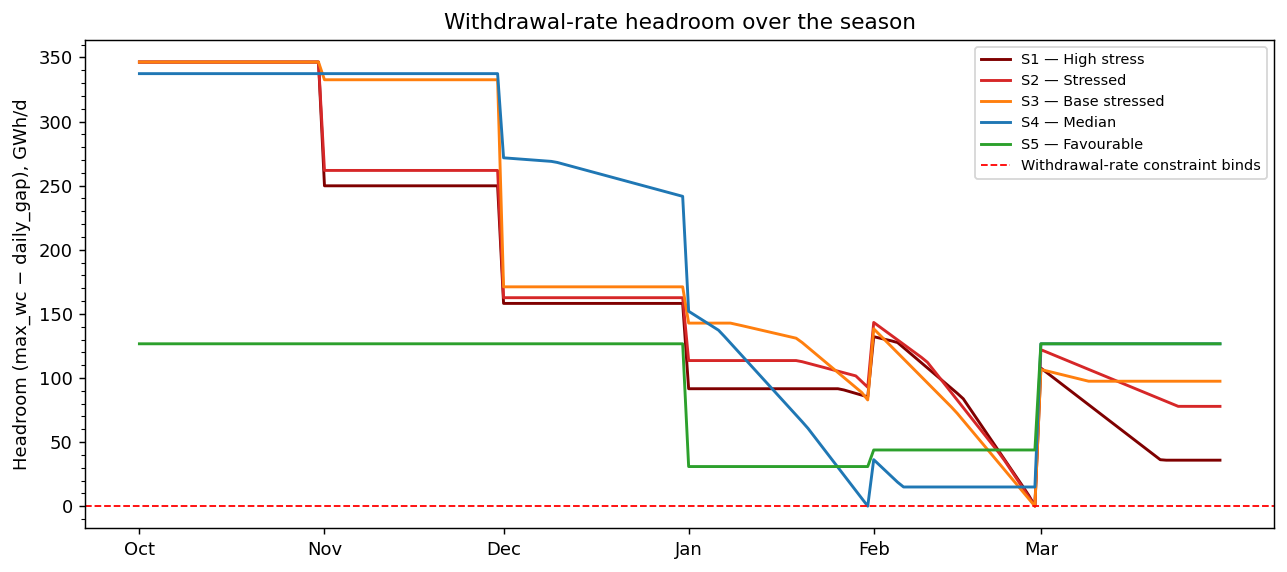

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for key, sc in SCENARIOS.items():
    info = main_results[key]
    if info["sim"] is None: continue
    h = info["sim"]["headroom_trajectory"]
    ax.plot(range(len(h)), h, color=sc["color"], lw=1.6, label=sc["label"])
ax.axhline(0, color="red", lw=1, ls="--", label="Withdrawal-rate constraint binds")
ax.set_xticks(month_starts); ax.set_xticklabels([MONTH_NAMES[m] for m in MONTH_ORDER])
ax.set_ylabel("Headroom (max_wc − daily_gap), GWh/d")
ax.set_title("Withdrawal-rate headroom over the season")
ax.legend(fontsize=8)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
fig.tight_layout()
fig.savefig("figs/storage_target_headroom.png", bbox_inches="tight")
fig;

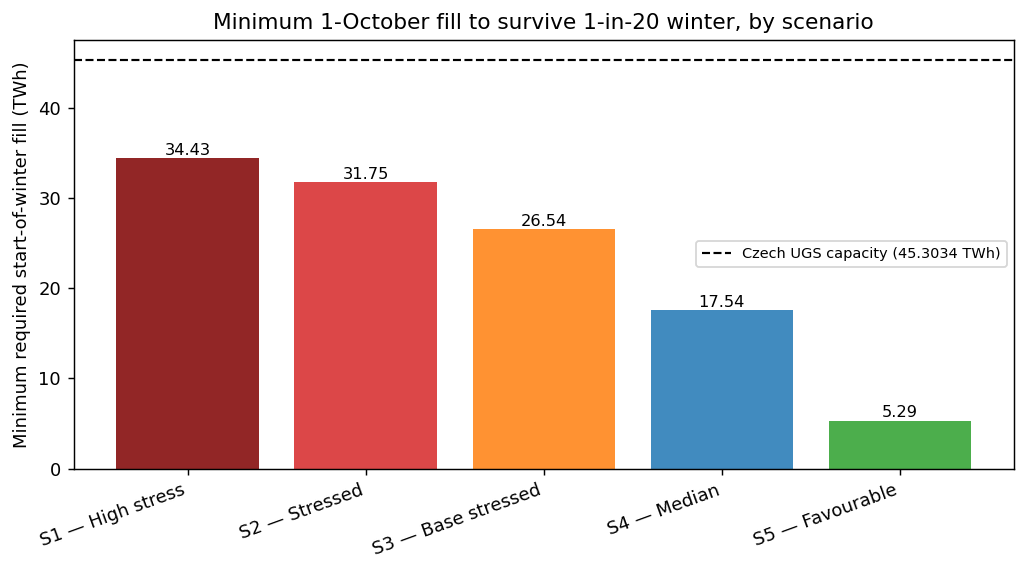

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
keys = list(SCENARIOS); xs = np.arange(len(keys))
twh = [main_results[k]["start_fill_pct"] * CAPACITY_TWH / 100 if main_results[k]["start_fill_pct"] is not None else 0
       for k in keys]
colors = [SCENARIOS[k]["color"] for k in keys]
ax.bar(xs, twh, color=colors, alpha=0.85)
ax.axhline(CAPACITY_TWH, color="black", lw=1.2, ls="--", label=f"Czech UGS capacity ({CAPACITY_TWH} TWh)")
for x, v in zip(xs, twh):
    ax.text(x, v + 0.4, f"{v:.2f}", ha="center", fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels([SCENARIOS[k]["label"] for k in keys], rotation=20, ha="right")
ax.set_ylabel("Minimum required start-of-winter fill (TWh)")
ax.set_title("Minimum 1-October fill to survive 1-in-20 winter, by scenario")
ax.legend(fontsize=8)
ax.set_ylim(0, CAPACITY_TWH * 1.05)
fig.tight_layout()
fig.savefig("figs/storage_target_bar.png", bbox_inches="tight")
fig;

---
## 8. Summary table

In [13]:
rows = []
for key, sc in SCENARIOS.items():
    info = main_results[key]
    f = info["start_fill_pct"]
    if f is None:
        rows.append({"Scenario": sc["label"], "Start fill (%)": "infeasible",
                     "Start fill (TWh)": "—", "Min fill reached (%)": "—",
                     "Binding constraint": "withdrawal rate at 100%"})
        continue
    sim = info["sim"]
    rows.append({
        "Scenario":             sc["label"],
        "Start fill (%)":       round(f, 2),
        "Start fill (TWh)":     round(f * CAPACITY_TWH / 100, 2),
        "Min fill reached (%)": round(sim["min_fill_pct"], 2),
        "Binding constraint":   info["binding"],
    })
summary = pd.DataFrame(rows).set_index("Scenario")
summary

,Start fill (%),Start fill (TWh),Min fill reached (%),Binding constraint
Scenario,,,,
S1 — High stress,76.00,34.43,20.32,withdrawal rate
S2 — Stressed,70.07,31.75,21.64,withdrawal rate
S3 — Base stressed,58.59,26.54,21.02,withdrawal rate
S4 — Median,38.73,17.54,16.79,withdrawal rate
S5 — Favourable,11.67,5.29,0.00,volume


---
## 9. Caveats

- **Deterministic imports** — month-specific percentiles applied as constants within each month. Real within-month variability would allow buffering across days, so results are upper-bound conservative (see Q1).
- **Withdrawal curve below 20% fill** is extrapolated flat from the lowest reliable bin; if the binding constraint is withdrawal-rate at low fill, the true target may be larger (see Q2).
- **Injection feasibility** between Apr–Sep is *not* checked; any start-of-winter target above ~35 TWh deserves an injection-side review (Q3).
- **Demand/import correlation** is unmodelled. Cold spells tighten German supply concurrently with Czech demand, so the deterministic 'P_k import × 1-in-20 demand' framing is optimistic in the joint tail (Q4).